In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


x = np.array([0.5, 0.8, 1.5, 2.1, 5.4, 3.2, 1.8, 0.9, 2.2, 0.7, 
              4.3, 3.8, 4.7, 6.4, 4.1, 3.1, 2.7, 1.6, 0.6, 1.1])
y = np.array([5.12, 7.06, 8.65, 11.78, 26.37, 19.91, 10.57, 7.39, 10.99, 9.36, 
              22.35, 22.30, 24.08, 29.91, 20.25, 18.53, 15.25, 11.04, 7.25, 10.08])

n = len(x)


In [2]:

# --- (a) ---
x_mean = np.mean(x)
y_mean = np.mean(y)

S_xy = np.sum((x - x_mean) * (y - y_mean))
S_xx = np.sum((x - x_mean)**2)
slope = S_xy / S_xx
intercept = y_mean - slope * x_mean


y_pred = intercept + slope * x
residuals = y - y_pred
variance_residuals = np.sum(residuals**2) / (n - 2) 
print(f"(a) Estimates:")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Variance of residuals: {variance_residuals:.4f}\n")


(a) Estimates:
Slope: 4.1827
Intercept: 4.1416
Variance of residuals: 1.9727



Text(0.5, 1.0, 'Residuals vs x')

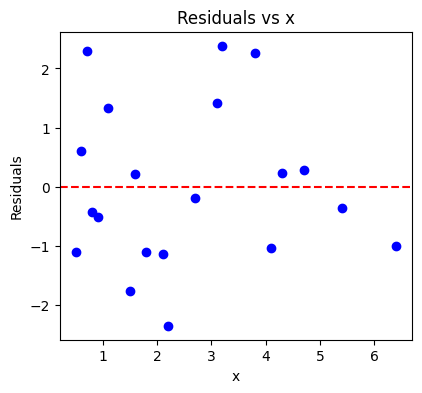

In [3]:

# --- (b)  ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(x, residuals, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('x')
plt.ylabel('Residuals')
plt.title('Residuals vs x')



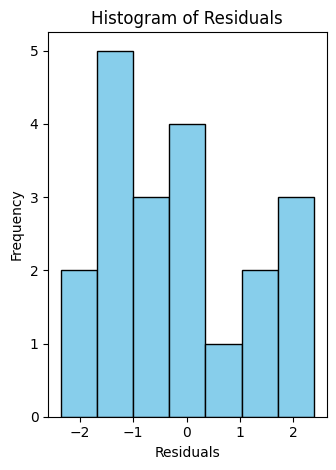

In [4]:

# --- (c)  ---
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=7, color='skyblue', edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.tight_layout()
plt.show()



In [5]:

# --- (d) ---
SS_res = np.sum(residuals**2)
SS_tot = np.sum((y - y_mean)**2)
r_squared = 1 - (SS_res / SS_tot)
print(f"(d) Coefficient of Determination (R^2): {r_squared:.4f}\n")



(d) Coefficient of Determination (R^2): 0.9659



In [6]:

# --- (e)  ---
x_new = 7
y_new_pred = intercept + slope * x_new

se_prediction = np.sqrt(variance_residuals * (1 + 1/n + (x_new - x_mean)**2 / S_xx))

t_crit = stats.t.ppf(0.95, df=n-2)

margin_of_error = t_crit * se_prediction
lower_bound = y_new_pred - margin_of_error
upper_bound = y_new_pred + margin_of_error

print(f"(e) Prediction for x = {x_new}:")
print(f"Predicted y: {y_new_pred:.4f}")
print(f"90% Prediction Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")

(e) Prediction for x = 7:
Predicted y: 33.4203
90% Prediction Interval: [30.5485, 36.2921]
